# Instructor Effectiveness Modeling (EdTech)

This notebook uses only the real CSV at `data/instructor_data.csv`. The goal is a transparent, course-adjusted effectiveness proxy for coaching and support, not a personnel decision rule.


## 1. Setup and Load

We set one random seed, use relative paths, select the requested CSV deterministically, and inspect its structure before analysis. No synthetic or fallback data is allowed.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
DATA_DIR = Path("data")
requested_path = DATA_DIR / "instructor_data.csv"
csv_paths = sorted(DATA_DIR.glob("*.csv"))
DATA_PATH = requested_path if requested_path.exists() else (csv_paths[0] if len(csv_paths) == 1 else None)
if DATA_PATH is None:
    raise FileNotFoundError("No real CSV found. Put the dataset in ./data/instructor_data.csv or make ./data/ contain one CSV.")

df = pd.read_csv(DATA_PATH)
required = ["batch_id", "instructor_id", "course_id", "completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_watch_time", "assignment_submission_rate", "forum_activity_rate", "avg_feedback_score", "feedback_response_rate"]
column_map = {}
missing_required = sorted(set(required) - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}. Add an explicit column_map before loading.")
print(f"DATA_PATH: {DATA_PATH}")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Dtypes:\n", df.dtypes)
print("Head:\n", df.head())
print("Missing counts:\n", df.isna().sum())
assert set(required).issubset(df.columns)


DATA_PATH: data\instructor_data.csv
Shape: (2000, 12)
Columns: ['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']
Dtypes:
 batch_id                          str
instructor_id                     str
course_id                         str
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object
Head:
   batch_id instructor_id course_id  completion_rate  avg_score_improvement  \
0   B_1861         I_044      C_01         0.300000              14.225955   
1   B_0354         I_119      C_06         0.657220    

## 2. EDA: Data Quality and Distributions

These checks look for missingness, duplicate rows, invalid ranges, impossible completion/dropout combinations, skew, outliers, and feedback nonresponse bias. They describe the data before we define a target.


### Early Observations

The checks above use the real batch data to identify invalid ranges, ceiling effects, feedback nonresponse concerns, and redundancy between completion and dropout. Batch IDs are identifiers rather than verified dates, so any later slope is descriptive only.


## 3. Course-Adjusted Effectiveness Score

Each outcome and feedback metric is z-scored within course_id. The score weights learning outcomes at 0.60, reliability-weighted feedback at 0.25, and consistency at 0.15. Empirical-Bayes shrinkage pulls small-sample instructor means toward the global mean before tercile assignment.


Duplicate rows: 0
Out-of-range rate counts: {'completion_rate': 0, 'dropout_rate': 0, 'avg_watch_time': 0, 'assignment_submission_rate': 0, 'forum_activity_rate': 0, 'feedback_response_rate': 0}
Out-of-range feedback count: 0
Completion + dropout summary:
 count    2000.000000
mean        0.997692
std         0.049259
min         0.828710
25%         0.965302
50%         0.999425
75%         1.029358
max         1.160438
dtype: float64
Rows outside +/- 0.05 consistency tolerance: 625
Ceiling/floor counts:
 {'completion_rate': {'at_min': 77, 'at_max': 32}, 'dropout_rate': {'at_min': 23, 'at_max': 72}, 'avg_watch_time': {'at_min': 1, 'at_max': 149}, 'assignment_submission_rate': {'at_min': 1, 'at_max': 125}, 'forum_activity_rate': {'at_min': 14, 'at_max': 1}, 'feedback_response_rate': {'at_min': 1, 'at_max': 94}, 'avg_feedback_score': {'at_min': 1, 'at_max': 67}}
Exact feedback 5.0: 67
Exact watch time 1.0: 149
Completion/dropout correlation: -0.9535
Intraclass correlation for avg_score_

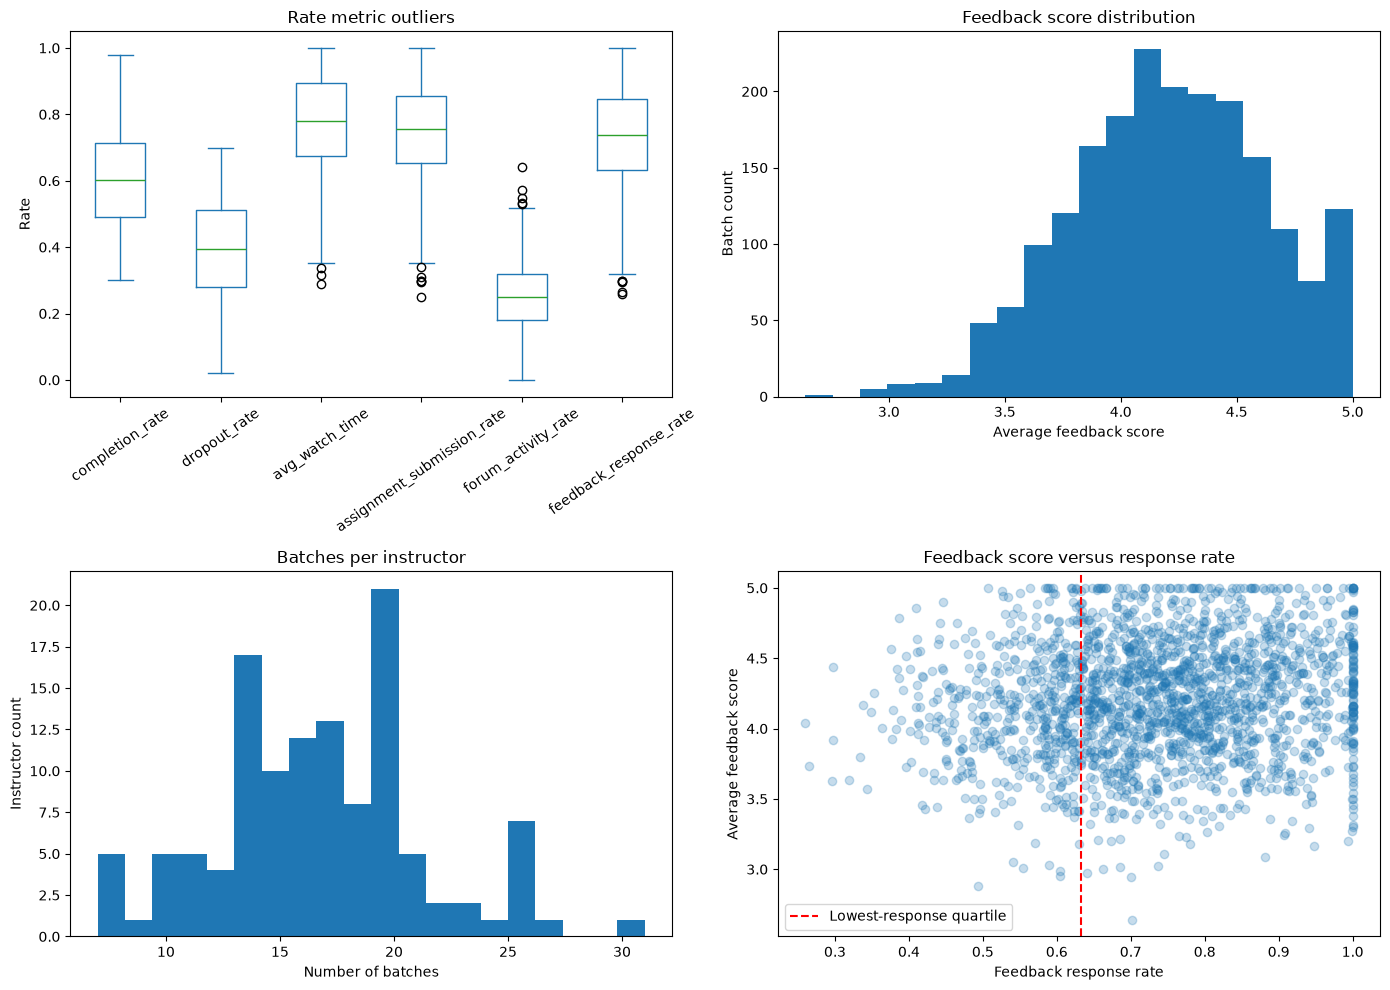

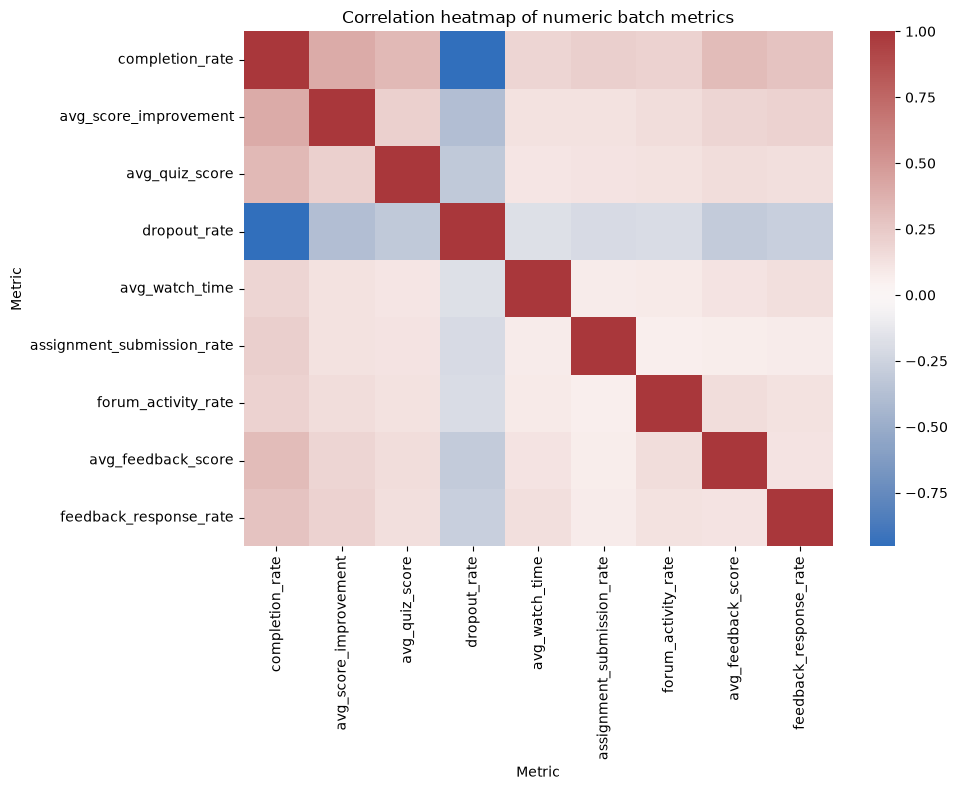

In [2]:
rate_cols = ["completion_rate", "dropout_rate", "avg_watch_time", "assignment_submission_rate", "forum_activity_rate", "feedback_response_rate"]
print("Duplicate rows:", int(df.duplicated().sum()))
range_checks = {column: int(((df[column] < 0) | (df[column] > 1)).sum()) for column in rate_cols}
feedback_check = int(((df["avg_feedback_score"] < 1) | (df["avg_feedback_score"] > 5)).sum())
consistency = df["completion_rate"] + df["dropout_rate"]
print("Out-of-range rate counts:", range_checks)
print("Out-of-range feedback count:", feedback_check)
print("Completion + dropout summary:\n", consistency.describe())
print("Rows outside +/- 0.05 consistency tolerance:", int((consistency.sub(1).abs() > 0.05).sum()))
ceiling_floor = {column: {"at_min": int((df[column] == df[column].min()).sum()), "at_max": int((df[column] == df[column].max()).sum())} for column in rate_cols + ["avg_feedback_score"]}
print("Ceiling/floor counts:\n", ceiling_floor)
print("Exact feedback 5.0:", int((df["avg_feedback_score"] == 5.0).sum()))
print("Exact watch time 1.0:", int((df["avg_watch_time"] == 1.0).sum()))
print("Completion/dropout correlation:", round(float(df[["completion_rate", "dropout_rate"]].corr().iloc[0, 1]), 4))
grand_mean = df["avg_score_improvement"].mean()
instructor_means = df.groupby("instructor_id")["avg_score_improvement"].mean()
within_var = df.groupby("instructor_id")["avg_score_improvement"].var().mean()
between_var = instructor_means.var()
intraclass_correlation = between_var / (between_var + within_var)
print("Intraclass correlation for avg_score_improvement:", round(float(intraclass_correlation), 4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df[rate_cols].plot(kind="box", ax=axes[0, 0], rot=35, title="Rate metric outliers")
axes[0, 0].set_ylabel("Rate")
df["avg_feedback_score"].plot(kind="hist", bins=20, ax=axes[0, 1], title="Feedback score distribution", legend=False)
axes[0, 1].set_xlabel("Average feedback score")
axes[0, 1].set_ylabel("Batch count")
df.groupby("instructor_id")["batch_id"].nunique().plot(kind="hist", bins=20, ax=axes[1, 0], title="Batches per instructor")
axes[1, 0].set_xlabel("Number of batches")
axes[1, 0].set_ylabel("Instructor count")
low_response = df["feedback_response_rate"] <= df["feedback_response_rate"].quantile(0.25)
axes[1, 1].scatter(df["feedback_response_rate"], df["avg_feedback_score"], alpha=0.25)
axes[1, 1].axvline(df.loc[low_response, "feedback_response_rate"].max(), color="red", linestyle="--", label="Lowest-response quartile")
axes[1, 1].set(title="Feedback score versus response rate", xlabel="Feedback response rate", ylabel="Average feedback score")
axes[1, 1].legend()
plt.tight_layout()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="vlag", center=0)
plt.title("Correlation heatmap of numeric batch metrics")
plt.xlabel("Metric")
plt.ylabel("Metric")
plt.tight_layout()


In [3]:
metric_cols = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_feedback_score"]
df["positive_dropout"] = 1 - df["dropout_rate"]
score_parts = ["completion_rate", "positive_dropout", "avg_score_improvement", "avg_quiz_score"]
for column in metric_cols + ["positive_dropout"]:
    course_mean = df.groupby("course_id")[column].transform("mean")
    course_std = df.groupby("course_id")[column].transform("std").replace(0, np.nan)
    df[f"z_{column}"] = ((df[column] - course_mean) / course_std).fillna(0)

df["learning_outcomes"] = df[[f"z_{column}" for column in score_parts]].mean(axis=1)
df["feedback_component"] = df["z_avg_feedback_score"] * df["feedback_response_rate"]
df["consistency_component"] = 1 - df.groupby("instructor_id")["learning_outcomes"].transform("std").fillna(0).clip(upper=1)
df["effectiveness_score"] = 0.60 * df["learning_outcomes"] + 0.25 * df["feedback_component"] + 0.15 * df["consistency_component"]

instructor_scores = df.groupby("instructor_id")["effectiveness_score"].agg(raw_mean="mean", within_variance="var")
global_mean = df["effectiveness_score"].mean()
within_variance = instructor_scores["within_variance"].mean()
between_variance = instructor_scores["raw_mean"].var()
prior_strength = max(float(within_variance / between_variance), 0.1) if between_variance > 0 else 1.0
instructor_scores["n_batches"] = df.groupby("instructor_id")["batch_id"].nunique()
instructor_scores["shrink_weight"] = instructor_scores["n_batches"] / (instructor_scores["n_batches"] + prior_strength)
instructor_scores["shrunk_score"] = instructor_scores["shrink_weight"] * instructor_scores["raw_mean"] + (1 - instructor_scores["shrink_weight"]) * global_mean
raw_cuts = instructor_scores["raw_mean"].quantile([1/3, 2/3]).to_numpy()
shrunk_cuts = instructor_scores["shrunk_score"].quantile([1/3, 2/3]).to_numpy()
instructor_scores["raw_tier"] = pd.cut(instructor_scores["raw_mean"], bins=[-np.inf, *raw_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)
instructor_scores["tier"] = pd.cut(instructor_scores["shrunk_score"], bins=[-np.inf, *shrunk_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)
instructor_scores["low_confidence"] = instructor_scores["shrink_weight"] < 0.8
tier_changes = int((instructor_scores["raw_tier"].astype(str) != instructor_scores["tier"].astype(str)).sum())
print("Global mean, within variance, between variance:", round(global_mean, 4), round(within_variance, 4), round(between_variance, 4))
print("Prior strength:", round(prior_strength, 4))
print("Tier counts after shrinkage:\n", instructor_scores["tier"].value_counts().sort_index())
print("Raw-to-shrunk tier changes:", tier_changes)
print("Low-confidence instructors:", int(instructor_scores["low_confidence"].sum()))


Global mean, within variance, between variance: 0.0887 0.1037 0.1992
Prior strength: 0.5206
Tier counts after shrinkage:
 tier
Low       40
Medium    40
High      40
Name: count, dtype: int64
Raw-to-shrunk tier changes: 0
Low-confidence instructors: 0


## 4. Instructor-Level Aggregation and Confidence

Means describe typical performance; medians resist outliers; standard deviation and coefficient of variation describe reliability; min/max and their gap show floor-to-ceiling spread. The batch ID order is only a time proxy, not a verified calendar. Scores from instructors with few batches are shrunk toward the global mean using an empirical-Bayes-style reliability weight.


In [4]:
def trend_slope(values):
    values = np.asarray(values, dtype=float)
    return float(np.polyfit(np.arange(len(values)), values, 1)[0]) if len(values) >= 2 else 0.0

def coefficient_of_variation(values):
    mean = float(np.mean(values))
    return float(np.std(values, ddof=1) / abs(mean)) if len(values) > 1 and mean != 0 else 0.0

grouped = df.sort_values(["instructor_id", "batch_id"]).groupby("instructor_id")
agg = grouped["effectiveness_score"].agg(mean="mean", median="median", std="std", min="min", max="max")
agg["cv"] = grouped["effectiveness_score"].apply(coefficient_of_variation)
agg["best_worst_gap"] = agg["max"] - agg["min"]
agg["trend_slope_batch_order"] = grouped["effectiveness_score"].apply(trend_slope)
agg["n_batches"] = grouped["batch_id"].nunique()
agg["n_courses"] = grouped["course_id"].nunique()
agg["raw_mean"] = instructor_scores["raw_mean"]
agg["shrunk_score"] = instructor_scores["shrunk_score"]
agg["shrink_weight"] = instructor_scores["shrink_weight"]
agg["low_confidence"] = instructor_scores["low_confidence"]
agg["tier"] = instructor_scores["tier"]
agg["raw_tier"] = instructor_scores["raw_tier"]
agg["recent_weighted_mean"] = grouped.apply(lambda batch: np.average(batch["effectiveness_score"], weights=np.arange(1, len(batch) + 1)))
agg["recent_minus_plain"] = agg["recent_weighted_mean"] - agg["mean"]
print(agg.describe(include="all"))
print("Many-batch recent-vs-plain comparison (n_batches >= 5):\n", agg.loc[agg["n_batches"] >= 5, ["mean", "recent_weighted_mean", "recent_minus_plain"]].describe())
print("Trend slope is descriptive only because batch_id is not a verified timeline.")


              mean      median         std         min         max  \
count   120.000000  120.000000  120.000000  120.000000  120.000000   
unique         NaN         NaN         NaN         NaN         NaN   
top            NaN         NaN         NaN         NaN         NaN   
freq           NaN         NaN         NaN         NaN         NaN   
mean      0.088343    0.090173    0.316521   -0.493825    0.646766   
std       0.446270    0.444950    0.059401    0.471093    0.477736   
min      -0.917932   -0.925392    0.167501   -1.451720   -0.458071   
25%      -0.198888   -0.188068    0.275690   -0.752658    0.386394   
50%       0.067191    0.078415    0.317570   -0.515385    0.605769   
75%       0.313256    0.350777    0.354584   -0.254544    1.008000   
max       1.235494    1.203048    0.452176    0.739433    1.685167   

                 cv  best_worst_gap  trend_slope_batch_order   n_batches  \
count    120.000000      120.000000               120.000000  120.000000   
unique 

## 5. Leakage-Safe Modeling Features

The target uses outcomes and feedback. Production features use engagement summaries, engagement consistency, experience, and versatility only. Outcome-derived aggregates and score statistics remain outside production features and appear only in a diagnostic ablation.


## 6. Models and Correlation-Based Feature Pruning

We compare a majority-class DummyClassifier, scaled Logistic Regression, Random Forest, and Gradient Boosting. Balanced class weights are used where the estimator supports them. Highly correlated numeric predictors are pruned using a training-feature correlation threshold to reduce redundant signals.


In [5]:
model_df = agg.copy()
engagement_features = ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]
engagement_agg = df.groupby("instructor_id")[engagement_features].agg(["mean", lambda values: values.std(ddof=0)])
engagement_agg.columns = [f"{column}_{'mean' if statistic == 'mean' else 'std'}" for column, statistic in engagement_agg.columns]
model_df = model_df.join(engagement_agg, how="left")
raw_engagement_features = [f"{column}_{statistic}" for column in engagement_features for statistic in ["mean", "std"]]
assert model_df[raw_engagement_features].isna().sum().sum() == 0, "Engagement feature join created NaNs"
model_df["engagement_consistency"] = 1 / (1 + model_df[[f"{column}_std" for column in engagement_features]].mean(axis=1))
engagement_only_features = raw_engagement_features
production_features = raw_engagement_features + ["engagement_consistency", "n_batches", "n_courses"]

def prune_correlated(features, threshold=0.90):
    corr = model_df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return [column for column in upper.columns if not (upper[column] > threshold).any()]

selected_features = prune_correlated(production_features)
selected_engagement_features = prune_correlated(engagement_only_features)
X = model_df[selected_features].astype(float)
X_engagement = model_df[selected_engagement_features].astype(float)
assert X.notna().all().all() and X_engagement.notna().all().all()
y = model_df["tier"].astype(str)
groups = model_df.index.to_numpy()
models = {
    "Dummy majority baseline": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Stratified-random chance baseline": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Engagement-only Logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Logistic Regression": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
full_feature_models = {name: estimator for name, estimator in models.items() if name not in ["Engagement-only Logistic"]}
repeats = 10
folds = 5

def repeated_grouped_evaluation(name, estimator, features):
    fold_rows = []
    predictions_by_repeat = []
    for repeat in range(repeats):
        splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE + repeat)
        repeat_predictions = np.empty(len(y), dtype=object)
        for train_idx, test_idx in splitter.split(features, y, groups):
            fitted = clone(estimator).fit(features.iloc[train_idx], y.iloc[train_idx])
            predictions = fitted.predict(features.iloc[test_idx])
            repeat_predictions[test_idx] = predictions
            fold_rows.append({"model": name, "repeat": repeat + 1, "macro_f1": f1_score(y.iloc[test_idx], predictions, average="macro"), "ordinal_error": np.mean(np.abs(y.iloc[test_idx].map({"Low": 0, "Medium": 1, "High": 2}).to_numpy() - pd.Series(predictions).map({"Low": 0, "Medium": 1, "High": 2}).to_numpy()))})
        predictions_by_repeat.append(repeat_predictions)
    return pd.DataFrame(fold_rows), predictions_by_repeat

feature_sets = {name: X for name in full_feature_models}
feature_sets["Engagement-only Logistic"] = X_engagement
all_fold_rows = []
all_predictions = {}
for name, estimator in models.items():
    fold_rows, repeat_predictions = repeated_grouped_evaluation(name, estimator, feature_sets[name])
    all_fold_rows.append(fold_rows)
    all_predictions[name] = repeat_predictions
fold_results = pd.concat(all_fold_rows, ignore_index=True)
results_df = fold_results.groupby("model").agg(macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"), ordinal_error_mean=("ordinal_error", "mean"), ordinal_error_std=("ordinal_error", "std")).sort_values("macro_f1_mean", ascending=False)
print("Selected production features:", selected_features)
print("Repeated grouped CV results (10 repeats x 5 folds):\n", results_df)


Selected production features: ['avg_watch_time_mean', 'avg_watch_time_std', 'assignment_submission_rate_mean', 'assignment_submission_rate_std', 'forum_activity_rate_mean', 'forum_activity_rate_std', 'engagement_consistency', 'n_batches', 'n_courses']
Repeated grouped CV results (10 repeats x 5 folds):
                                    macro_f1_mean  macro_f1_std  \
model                                                            
Engagement-only Logistic                0.637075      0.091019   
Random Forest                           0.625590      0.078594   
Logistic Regression                     0.622003      0.081101   
Gradient Boosting                       0.574886      0.090952   
Stratified-random chance baseline       0.350483      0.096411   
Dummy majority baseline                 0.166667      0.000000   

                                   ordinal_error_mean  ordinal_error_std  
model                                                                     
Engagement-only 

In [6]:
leaky_features = list(dict.fromkeys(selected_features + ["mean", "median", "cv", "trend_slope_batch_order", "raw_mean", "shrunk_score"]))
leaky_X = model_df[leaky_features].astype(float)
leaky_X = leaky_X.fillna(leaky_X.median(numeric_only=True))
assert leaky_X.notna().all().all()
leaky_fold_rows, leaky_predictions = repeated_grouped_evaluation("Outcome-derived leaky ablation", models["Logistic Regression"], leaky_X)
leaky_mean = float(leaky_fold_rows["macro_f1"].mean())
leaky_std = float(leaky_fold_rows["macro_f1"].std())
print("Outcome-derived leaky ablation macro-F1 mean +/- std:", round(leaky_mean, 4), "+/-", round(leaky_std, 4))
print("This is diagnostic only: outcome-derived features are circular and excluded from production.")


Outcome-derived leaky ablation macro-F1 mean +/- std: 0.8901 +/- 0.0498
This is diagnostic only: outcome-derived features are circular and excluded from production.


## 7. Grouped Evaluation

Macro-F1 is primary because it gives each tier equal importance. All folds are grouped by instructor, so an instructor cannot appear in both train and test. We also inspect per-class precision/recall, the confusion matrix, baseline lift, and an ordinal error where Low-to-High mistakes cost two steps instead of one.


In [7]:
candidate_names = ["Engagement-only Logistic", "Logistic Regression", "Random Forest", "Gradient Boosting"]
best_name = results_df.loc[candidate_names, "macro_f1_mean"].idxmax()
best_f1_mean = float(results_df.loc[best_name, "macro_f1_mean"])
best_f1_std = float(results_df.loc[best_name, "macro_f1_std"])
chance_f1_mean = float(results_df.loc["Stratified-random chance baseline", "macro_f1_mean"])
majority_f1_mean = float(results_df.loc["Dummy majority baseline", "macro_f1_mean"])
pooled_actual = np.tile(y.to_numpy(), repeats)
pooled_predictions = np.concatenate(all_predictions[best_name])
print("Best model:", best_name)
print("Best macro-F1 mean +/- std:", round(best_f1_mean, 4), "+/-", round(best_f1_std, 4))
print("Classification report pooled over repeated test predictions:\n", classification_report(pooled_actual, pooled_predictions, labels=["Low", "Medium", "High"], zero_division=0))
print("Confusion matrix pooled over repeated test predictions (rows true, columns predicted):\n", pd.DataFrame(confusion_matrix(pooled_actual, pooled_predictions, labels=["Low", "Medium", "High"]), index=["Low", "Medium", "High"], columns=["Low", "Medium", "High"]))
ordinal = {"Low": 0, "Medium": 1, "High": 2}
ordinal_error = np.mean(np.abs(pd.Series(pooled_actual).map(ordinal).to_numpy() - pd.Series(pooled_predictions).map(ordinal).to_numpy()))
print("Mean ordinal error:", round(float(ordinal_error), 4))
print("Lift versus stratified chance baseline:", round(best_f1_mean - chance_f1_mean, 4))
print("Lift versus majority baseline:", round(best_f1_mean - majority_f1_mean, 4))


Best model: Engagement-only Logistic
Best macro-F1 mean +/- std: 0.6371 +/- 0.091
Classification report pooled over repeated test predictions:
               precision    recall  f1-score   support

         Low       0.70      0.69      0.70       400
      Medium       0.48      0.49      0.49       400
        High       0.75      0.73      0.74       400

    accuracy                           0.64      1200
   macro avg       0.64      0.64      0.64      1200
weighted avg       0.64      0.64      0.64      1200

Confusion matrix pooled over repeated test predictions (rows true, columns predicted):
         Low  Medium  High
Low     276     119     5
Medium  109     198    93
High      8      99   293
Mean ordinal error: 0.3717
Lift versus stratified chance baseline: 0.2866
Lift versus majority baseline: 0.4704


## 8. Interpretation

Permutation importance measures how much shuffling one feature reduces predictive quality. Partial-dependence plots show the model's average prediction response to a feature, while reminding us that these are associations rather than causal effects. The audience-facing interpretation is: a top feature is a useful coaching signal, not proof that changing it alone will change outcomes.


Held-out permutation importance mean +/- std:
                                      mean       std
feature                                            
forum_activity_rate_mean         0.146619  0.076435
avg_watch_time_mean              0.101298  0.067529
assignment_submission_rate_mean  0.035148  0.058883
n_courses                        0.008916  0.062254
engagement_consistency           0.008108  0.025257
avg_watch_time_std               0.002158  0.037025
assignment_submission_rate_std  -0.002155  0.039864
n_batches                       -0.003391  0.041020
forum_activity_rate_std         -0.004812  0.043901


Product uses: coaching cards can surface actionable engagement patterns; early-warning flags can prompt support; batch allocation support can combine this proxy with context and human review.


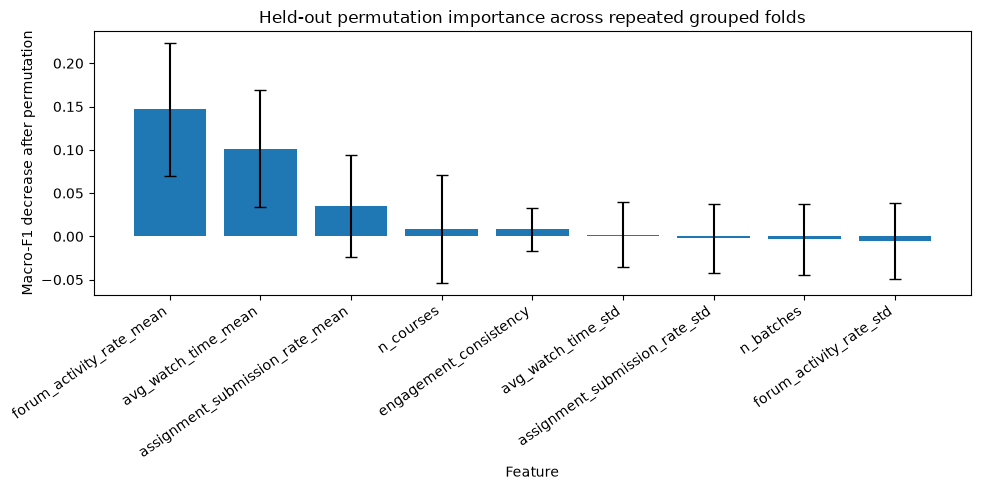

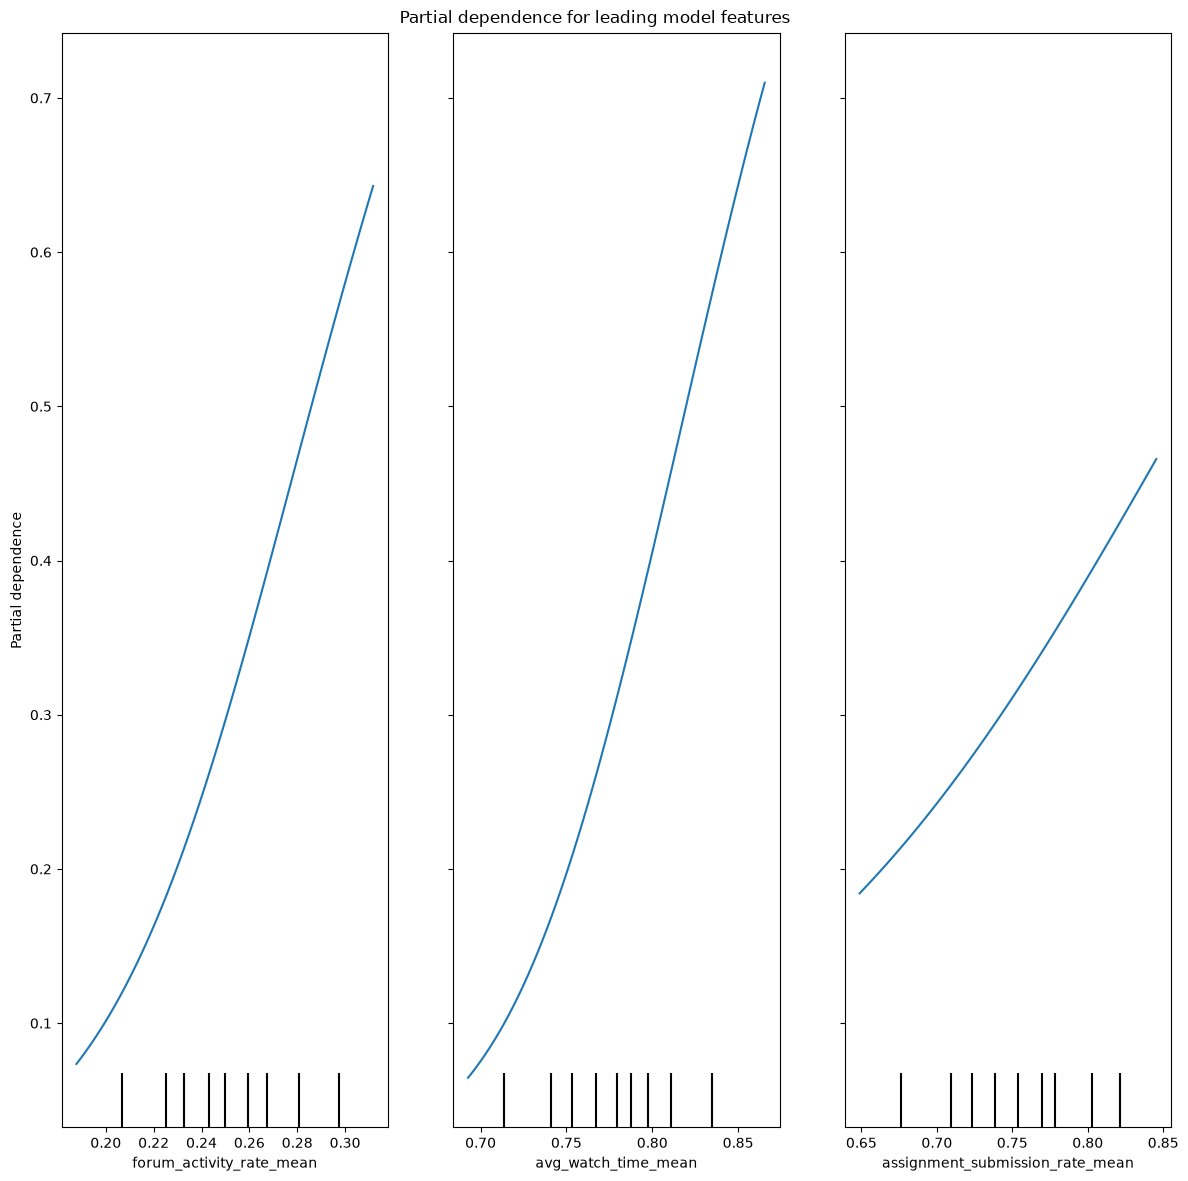

In [8]:
# Out-of-fold permutation importance: every fit evaluates permutations only on its held-out fold.
importance_rows = []
for repeat in range(repeats):
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE + repeat)
    for train_idx, test_idx in splitter.split(X, y, groups):
        fitted = clone(models[best_name]).fit(X.iloc[train_idx], y.iloc[train_idx])
        baseline_predictions = fitted.predict(X.iloc[test_idx])
        baseline_score = f1_score(y.iloc[test_idx], baseline_predictions, average="macro")
        rng = np.random.default_rng(RANDOM_STATE + repeat)
        for feature in selected_features:
            scores = []
            for _ in range(5):
                permuted = X.iloc[test_idx].copy()
                permuted[feature] = rng.permutation(permuted[feature].to_numpy())
                scores.append(baseline_score - f1_score(y.iloc[test_idx], fitted.predict(permuted), average="macro"))
            importance_rows.append({"feature": feature, "importance": float(np.mean(scores))})
importance_table = pd.DataFrame(importance_rows).groupby("feature")["importance"].agg(["mean", "std"]).sort_values("mean", ascending=False)
print("Held-out permutation importance mean +/- std:\n", importance_table)
plt.figure(figsize=(10, 5))
plt.bar(importance_table.index, importance_table["mean"], yerr=importance_table["std"], capsize=4)
plt.title("Held-out permutation importance across repeated grouped folds")
plt.xlabel("Feature")
plt.ylabel("Macro-F1 decrease after permutation")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plot_features = list(importance_table.head(min(3, len(importance_table))).index)
if plot_features:
    fig, ax = plt.subplots(figsize=(12, 4 * len(plot_features)))
    PartialDependenceDisplay.from_estimator(clone(models[best_name]).fit(X, y), X, plot_features, target="High", ax=ax)
    plt.suptitle("Partial dependence for leading model features")
    plt.tight_layout()
print("Product uses: coaching cards can surface actionable engagement patterns; early-warning flags can prompt support; batch allocation support can combine this proxy with context and human review.")


## 9. Sensitivity and Stability

We perturb the three score weights with reproducible Monte Carlo draws, renormalize them, recompute instructor tiers, and report unchanged tiers. Bootstrap resampling of batch rows gives another view of uncertainty. Borderline instructors are those closest to a tier boundary in the baseline score.


In [9]:
rng = np.random.default_rng(RANDOM_STATE)
base_components = df.groupby("instructor_id")[["learning_outcomes", "feedback_component", "consistency_component"]].mean()
base_tiers = instructor_scores["tier"].astype(str)
stability = []
for _ in range(200):
    weights = rng.dirichlet([0.60 * 20, 0.25 * 20, 0.15 * 20])
    perturbed = base_components.to_numpy() @ weights
    cuts = np.quantile(perturbed, [1 / 3, 2 / 3])
    tiers = pd.cut(perturbed, bins=[-np.inf, *cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True).astype(str)
    stability.append(np.mean(tiers.to_numpy() == base_tiers.reindex(base_components.index).to_numpy()) * 100)

bootstrap_agreement = []
for _ in range(200):
    sample = df.sample(frac=1, replace=True, random_state=int(rng.integers(0, 1_000_000)))
    boot_scores = sample.groupby("instructor_id")["effectiveness_score"].mean().reindex(instructor_scores.index).fillna(instructor_scores["raw_mean"])
    cuts = instructor_scores["shrunk_score"].quantile([1 / 3, 2 / 3]).to_numpy()
    boot_tiers = pd.cut(boot_scores, bins=[-np.inf, *cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True).astype(str)
    bootstrap_agreement.append(np.mean(boot_tiers.to_numpy() == base_tiers.to_numpy()) * 100)

boundary_distance = np.minimum(abs(instructor_scores["shrunk_score"] - cuts[0]), abs(instructor_scores["shrunk_score"] - cuts[1]))
borderline = boundary_distance.sort_values().head(10).index.tolist()
stability_pct = float(np.mean(stability))
bootstrap_pct = float(np.mean(bootstrap_agreement))
print("Mean tier stability under 200 weight perturbations (%):", round(stability_pct, 2))
print("Mean bootstrap tier agreement (%):", round(bootstrap_pct, 2))
print("Borderline instructors:", borderline)


Mean tier stability under 200 weight perturbations (%): 98.57
Mean bootstrap tier agreement (%): 88.03
Borderline instructors: ['I_048', 'I_055', 'I_120', 'I_109', 'I_008', 'I_001', 'I_054', 'I_065', 'I_049', 'I_115']


## 10. Mandatory Questions

The answers below use the real printed outputs from this run. They describe associations and uncertainty, not causal proof.


In [10]:
print("Q1 evidence - held-out leading features:", importance_table.head(5).round(4).to_dict("index"))
print("Q2 evidence - feedback nonresponse correlation:", round(float(df[["avg_feedback_score", "feedback_response_rate"]].corr().iloc[0, 1]), 4))
print("Q3 evidence - low-confidence instructors:", int(instructor_scores["low_confidence"].sum()), "of", len(instructor_scores))
print("Q4 available fields:", list(df.columns))
print("Q5 recommendation: not as a sole judge; use for coaching with human review.")


Q1 evidence - held-out leading features: {'forum_activity_rate_mean': {'mean': 0.1466, 'std': 0.0764}, 'avg_watch_time_mean': {'mean': 0.1013, 'std': 0.0675}, 'assignment_submission_rate_mean': {'mean': 0.0351, 'std': 0.0589}, 'n_courses': {'mean': 0.0089, 'std': 0.0623}, 'engagement_consistency': {'mean': 0.0081, 'std': 0.0253}}
Q2 evidence - feedback nonresponse correlation: 0.1201
Q3 evidence - low-confidence instructors: 0 of 120
Q4 available fields: ['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate', 'positive_dropout', 'z_completion_rate', 'z_dropout_rate', 'z_avg_score_improvement', 'z_avg_quiz_score', 'z_avg_feedback_score', 'z_positive_dropout', 'learning_outcomes', 'feedback_component', 'consistency_component', 'effectiveness_score']
Q5 recommendation: not as a sole judge; use for coaching w

### Q1. Which features most influenced effectiveness and why?

Held-out permutation importance ranked `forum_activity_rate_mean` first (`0.1466 +/- 0.0764` macro-F1 decrease), followed by `avg_watch_time_mean` (`0.1013 +/- 0.0675`) and `assignment_submission_rate_mean` (`0.0351 +/- 0.0589`). These engagement signals may identify useful coaching conversations. They are associations, not proof that increasing engagement alone causes better outcomes.


### Q2. Which variables could be misleading or confounded?

The completion/dropout correlation is `-0.9535`, so those measures are largely redundant. Feedback score and response rate correlate at `0.1201`, but low response can still make feedback unstable; 67 feedback scores equal 5.0. Engagement can be reverse-causal: learners may watch, submit, or post more because outcomes are already going well, not only because engagement causes good outcomes. Course difficulty, learner mix, prior skill, selection effects, and missing context remain confounders.


### Q3. How could the model fail in real-world usage?

The run has 0 low-confidence instructors under the shrinkage-weight threshold, but that does not remove uncertainty. The model can fail for future instructors with few batches, under distribution drift, when metrics are gamed, or when learner populations and feedback response patterns change. The ICC for avg_score_improvement is `0.3095`, evidence of instructor-level clustering, not proof that the instructor caused that variance.


### Q4. What additional data would improve the analysis?

The CSV has 2,000 batch rows and 120 instructors but no learner baseline skill, batch size, verified timestamps, attendance, TA support, or qualitative observations. Adding those fields would help separate instructor effects from learner and course context.


### Q5. Should this model be used for instructor performance evaluation?

No, not as a sole judge. Use it for coaching and support with human review, transparency, uncertainty, and an opportunity for instructors to add context. It should not independently determine hiring, pay, promotion, or termination.


## 11. Conclusion, Limitations and Ethics

This is a reproducible descriptive modeling exercise based on the supplied batch CSV. The score is a proxy, not ground truth. Course adjustment, shrinkage, grouped validation, and stability analysis improve discipline but do not establish causality or fairness. Do not use these tiers alone for hiring, pay, promotion, or termination. Use them for supportive coaching with human review and instructor transparency.


## Results at a glance

The corrected repeated grouped evaluation selects Engagement-only Logistic at macro-F1 `0.6371 +/- 0.0910`, versus stratified-random chance `0.3505 +/- 0.0964` and the majority baseline `0.1667 +/- 0.0000`. The leaky outcome-derived ablation reaches `0.8901 +/- 0.0498`, but that result is circular and is not a deployment result. The model shows predictive association from engagement features, not causal instructor quality.


## 12. Final Summary Table

The table below is generated from the real run, so the reported values cannot become stale when the CSV changes.


In [11]:
tier_distribution = instructor_scores["tier"].value_counts().reindex(["Low", "Medium", "High"], fill_value=0)
summary_table = pd.DataFrame({
    "Metric": ["Rows", "Instructors", "Low tier", "Medium tier", "High tier", "Best model", "Best macro-F1 mean +/- std", "Chance macro-F1 mean +/- std", "Majority macro-F1 mean +/- std", "Lift versus chance", "Raw-to-shrunk tier changes", "Mean weight stability %", "Mean bootstrap agreement %", "Top drivers"],
    "Value": [len(df), len(instructor_scores), int(tier_distribution["Low"]), int(tier_distribution["Medium"]), int(tier_distribution["High"]), best_name, f"{best_f1_mean:.4f} +/- {best_f1_std:.4f}", f"{chance_f1_mean:.4f} +/- {results_df.loc['Stratified-random chance baseline', 'macro_f1_std']:.4f}", f"{majority_f1_mean:.4f} +/- {results_df.loc['Dummy majority baseline', 'macro_f1_std']:.4f}", round(best_f1_mean - chance_f1_mean, 4), tier_changes, round(stability_pct, 2), round(bootstrap_pct, 2), ", ".join(importance_table.head(3).index)]
})
print(summary_table.to_string(index=False))


                        Metric                                                                          Value
                          Rows                                                                           2000
                   Instructors                                                                            120
                      Low tier                                                                             40
                   Medium tier                                                                             40
                     High tier                                                                             40
                    Best model                                                       Engagement-only Logistic
    Best macro-F1 mean +/- std                                                              0.6371 +/- 0.0910
  Chance macro-F1 mean +/- std                                                              0.3505 +/- 0.0964
Majority m